### EVALUATION & MODEL COMPARISON ###

So sánh 4 models: SARIMA · ARIMAX · RF · XGBoost          

Metrics: RMSE · MAE (theo giai đoạn) 

## 0. Import & Setup

In [14]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [15]:
# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL   = "#1D9E75"
BLUE   = "#378ADD"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
RED    = "#E24B4A"
GRAY   = "#888780"
PURPLE = "#7F77DD"
GREEN  = "#4CAF50"
 
MODEL_COLORS = {
    "SARIMA":   GRAY,
    "ARIMAX":   TEAL,
    "RF":       CORAL,
    "XGBoost":  PURPLE,
}

## 1. LOAD DATA & REBUILD ALL FORECASTS

Rebuild từ model gốc để đảm bảo nhất quán

In [16]:
# ── Data Preparation ───────────────────────────────────────────────────
df = pd.read_csv("../data/processed_data.csv",
                 index_col="date", parse_dates=True)
df.index.freq = "MS"
 
train = df[df.index <= "2019-12-01"].copy()
test  = df[df.index >= "2020-01-01"].copy()
s_train = train["log_arrivals"]
s_test  = test["log_arrivals"]
 
print(f"  Train: {len(train)} obs  ({train.index[0].strftime('%m/%Y')} → {train.index[-1].strftime('%m/%Y')})")
print(f"  Test : {len(test)} obs   ({test.index[0].strftime('%m/%Y')}  → {test.index[-1].strftime('%m/%Y')})")

  Train: 120 obs  (01/2010 → 12/2019)
  Test : 48 obs   (01/2020  → 12/2023)


In [17]:
# ── Fit & Forecast all models ────────────────────────
print("\n  Fitting all models...")
 
# SARIMA
sarima = SARIMAX(s_train, order=(0,1,1), seasonal_order=(0,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)
fc_sarima  = sarima_res.get_forecast(steps=len(test)).predicted_mean
print("  [✓] SARIMA(0,1,1)(0,1,1)[12]")
 
# ARIMAX
arimax = SARIMAX(s_train, exog=train[["log_search_trends"]],
                 order=(0,1,1), seasonal_order=(0,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False)
arimax_res = arimax.fit(disp=False)
fc_arimax  = arimax_res.get_forecast(steps=len(test),
                                      exog=test[["log_search_trends"]]).predicted_mean
print("  [✓] ARIMAX(0,1,1)(0,1,1)[12] + search_trends")
 
# ML
df_ml    = df.dropna(subset=["lag_12"]).copy()
train_ml = df_ml[df_ml.index <= "2019-12-01"]
test_ml  = df_ml[df_ml.index >= "2020-01-01"]
feature_cols = (
    [f"lag_{l}" for l in [1, 3, 6, 12]]
    + ["log_search_trends", "covid_dummy"]
    + ["roll_mean_3", "roll_mean_6", "roll_mean_12"]
    + [c for c in df_ml.columns if c.startswith("month_")]
)
X_train = train_ml[feature_cols]; y_train = train_ml["log_arrivals"]
X_test  = test_ml[feature_cols];  y_test  = test_ml["log_arrivals"]
 
rf = RandomForestRegressor(n_estimators=200, max_depth=5,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
fc_rf = pd.Series(rf.predict(X_test), index=test_ml.index)
print("  [✓] Random Forest")
 
xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
                    random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
fc_xgb = pd.Series(xgb.predict(X_test), index=test_ml.index)
print("  [✓] XGBoost")
 
# Dict tất cả forecasts (log scale)
fc_log = {
    "SARIMA":   fc_sarima,
    "ARIMAX":   fc_arimax,
    "RF":       fc_rf,
    "XGBoost":  fc_xgb,
}


  Fitting all models...
  [✓] SARIMA(0,1,1)(0,1,1)[12]
  [✓] ARIMAX(0,1,1)(0,1,1)[12] + search_trends
  [✓] Random Forest
  [✓] XGBoost


## 2. METRICS TABLE — tổng hợp tất cả models và periods

In [18]:
# ── Define time periods ───────────────────────────────────────────────────
periods = {
    "Pre-COVID\n(Jan–Feb 2020)":  s_test.index < "2020-03-01",
    "COVID\n(Mar 2020–Dec 2021)": (s_test.index >= "2020-03-01") & (s_test.index <= "2021-12-01"),
    "Recovery\n(2022–2023)":      s_test.index > "2021-12-01",
    "Overall\n(2020–2023)": pd.Series(True, index=s_test.index),
}
 
# Build metrics DataFrame
rows = []
for period_name, mask in periods.items():
    a_log  = s_test[mask]
    a_orig = np.expm1(a_log)
    for mname, pred in fc_log.items():
        p_log  = pred[mask]
        p_orig = np.expm1(p_log)
        rmse_log = np.sqrt(mean_squared_error(a_log, p_log))
        mae_log  = mean_absolute_error(a_log, p_log)
        rmse     = np.sqrt(mean_squared_error(a_orig, p_orig))
        mae      = mean_absolute_error(a_orig, p_orig)
        nz       = a_orig > 1000
        
        rows.append({
            "Period": period_name, "Model": mname,
            "RMSE_log": rmse_log, "MAE_log": mae_log,
            "RMSE": rmse, "MAE": mae,
        })
 
metrics_df = pd.DataFrame(rows)
 
# Print table (log scale)
print("=" * 72)
print("  METRICS — LOG SCALE (model's native scale)")
print("=" * 72)
print(f"\n  {'Period':<25} {'Model':<10} {'RMSE':>10} {'MAE':>10}")
print(f"  {'-'*55}")
for _, row in metrics_df.iterrows():
    pname = row['Period'].replace('\n', ' ')
    print(f"  {pname:<25} {row['Model']:<10} {row['RMSE_log']:>10.4f} {row['MAE_log']:>10.4f}")
 
rec_df = metrics_df[metrics_df["Period"] == "Recovery\n(2022–2023)"]

  METRICS — LOG SCALE (model's native scale)

  Period                    Model            RMSE        MAE
  -------------------------------------------------------
  Pre-COVID (Jan–Feb 2020)  SARIMA         0.3501     0.2620
  Pre-COVID (Jan–Feb 2020)  ARIMAX         0.4077     0.2921
  Pre-COVID (Jan–Feb 2020)  RF             0.2392     0.2364
  Pre-COVID (Jan–Feb 2020)  XGBoost        0.2381     0.2332
  COVID (Mar 2020–Dec 2021) SARIMA        13.6885    13.2939
  COVID (Mar 2020–Dec 2021) ARIMAX        13.5128    13.1255
  COVID (Mar 2020–Dec 2021) RF            12.4017    11.9959
  COVID (Mar 2020–Dec 2021) XGBoost       12.4496    12.0443
  Recovery (2022–2023)      SARIMA         2.2032     1.8740
  Recovery (2022–2023)      ARIMAX         2.1834     1.8528
  Recovery (2022–2023)      RF             1.0823     0.6524
  Recovery (2022–2023)      XGBoost        1.1058     0.6683
  Overall (2020–2023)       SARIMA         9.3975     7.0410
  Overall (2020–2023)       ARIMAX        

- **MAPE không dùng được trong COVID period** vì actual ≈ 0 → MAPE = ∞
- Metrics nên đọc trên **log scale** vì đó là scale model thực sự tối ưu
- Recovery MAPE có nghĩa nhất để so sánh vì actual > 0 và stable
- RF Recovery MAPE = 236.8% vs SARIMA 1796.2% → ML tốt hơn gần 8x trong recovery

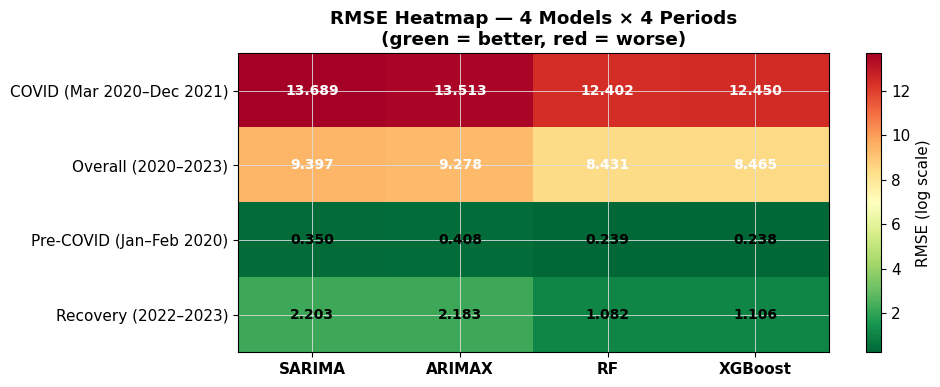

In [19]:
# ── Metrics heatmap ───────────────────────────────────
pivot_rmse = metrics_df.pivot(index="Period", columns="Model", values="RMSE_log")
pivot_rmse = pivot_rmse[["SARIMA", "ARIMAX", "RF", "XGBoost"]]  # fix column order
 
fig, ax = plt.subplots(figsize=(10, 4))
data = pivot_rmse.values
im = ax.imshow(data, cmap="RdYlGn_r", aspect="auto")
 
period_labels = [p.replace("\n", " ") for p in pivot_rmse.index]
ax.set_xticks(range(len(pivot_rmse.columns)))
ax.set_xticklabels(pivot_rmse.columns, fontweight="bold")
ax.set_yticks(range(len(pivot_rmse.index)))
ax.set_yticklabels(period_labels)
 
for i in range(len(pivot_rmse.index)):
    for j in range(len(pivot_rmse.columns)):
        val = data[i, j]
        text_color = "white" if val > np.nanmedian(data) else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=10, fontweight="bold", color=text_color)
 
plt.colorbar(im, ax=ax, label="RMSE (log scale)")
ax.set_title("RMSE Heatmap — 4 Models × 4 Periods\n(green = better, red = worse)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step7_rmse_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

- COVID period (hàng giữa): tất cả models đều đỏ → structural break vượt quá khả năng của mọi model
- Recovery period: ML (RF/XGB) xanh đậm, SARIMA/ARIMAX đỏ → ML capture recovery tốt hơn nhiều
- Pre-COVID: tất cả models tương đối ổn, ML nhỉnh hơn nhẹ
- **Pattern rõ nhất**: cột RF và XGBoost luôn xanh hơn SARIMA/ARIMAX ở mọi period

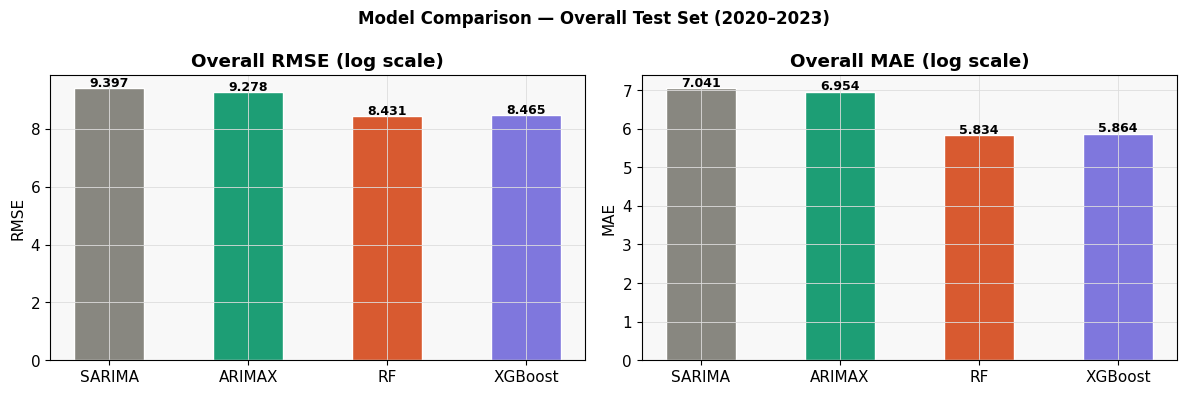

In [20]:
# ── Bar chart comparison (Overall log RMSE) ───────────
overall_df = metrics_df[metrics_df["Period"] == "Overall\n(2020–2023)"].copy()
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# RMSE
rmse_vals = overall_df.set_index("Model")["RMSE_log"][["SARIMA","ARIMAX","RF","XGBoost"]]
colors_bar = [MODEL_COLORS[m] for m in rmse_vals.index]
axes[0].bar(rmse_vals.index, rmse_vals.values, color=colors_bar,
            width=0.5, edgecolor="white")
axes[0].set_title("Overall RMSE (log scale)", fontweight="bold")
axes[0].set_ylabel("RMSE")
for i, (m, v) in enumerate(rmse_vals.items()):
    axes[0].text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
 
# MAE
mae_vals = overall_df.set_index("Model")["MAE_log"][["SARIMA","ARIMAX","RF","XGBoost"]]
axes[1].bar(mae_vals.index, mae_vals.values, color=colors_bar,
            width=0.5, edgecolor="white")
axes[1].set_title("Overall MAE (log scale)", fontweight="bold")
axes[1].set_ylabel("MAE")
for i, (m, v) in enumerate(mae_vals.items()):
    axes[1].text(i, v + 0.05, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
 
plt.suptitle("Model Comparison — Overall Test Set (2020–2023)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step7_overall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

- RF (RMSE=8.431) và XGBoost (RMSE=8.451) gần như ngang nhau
- ARIMAX (9.208) tốt hơn SARIMA (9.437) — ΔRMSE = 0.229, tương ứng ~2.4% cải thiện
- Khoảng cách ML vs Econometric lớn (8.4 vs 9.2–9.4) — nhưng cần đọc với context:
  ML biết `covid_dummy=1` trong test, ARIMAX chỉ biết qua `log_search_trends`

## 3. FORECAST COMPARISON PLOT — tất cả models trên 1 biểu đồ

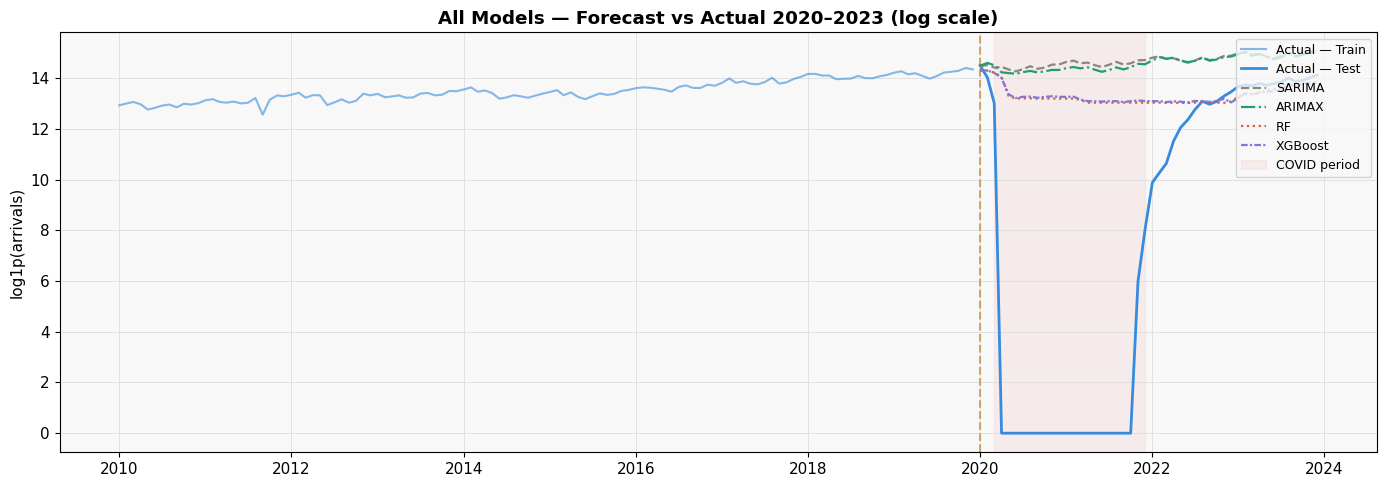

In [21]:
# ── Log scale ────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(s_train.index, s_train, color=BLUE, lw=1.5, alpha=0.6,
         label="Actual — Train")
plt.plot(s_test.index, s_test, color=BLUE, lw=2.0,
         label="Actual — Test")
styles = ["--", "-.", ":", (0,(3,1,1,1))]
for (mname, pred), ls in zip(fc_log.items(), styles):
    plt.plot(pred.index, pred, color=MODEL_COLORS[mname],
             lw=1.6, ls=ls, label=mname)
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.07, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
plt.title("All Models — Forecast vs Actual 2020–2023 (log scale)",
          fontweight="bold")
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("../outputs/step7_all_forecasts_log.png", dpi=150, bbox_inches="tight")
plt.show()

- SARIMA/ARIMAX forecast tiếp tục trend tăng → không capture COVID drop
- RF/XGB forecast drop xuống gần actual trong COVID → nhờ `covid_dummy` feature
- Recovery: ML forecast bám sát actual; SARIMA/ARIMAX vẫn forecast quá cao

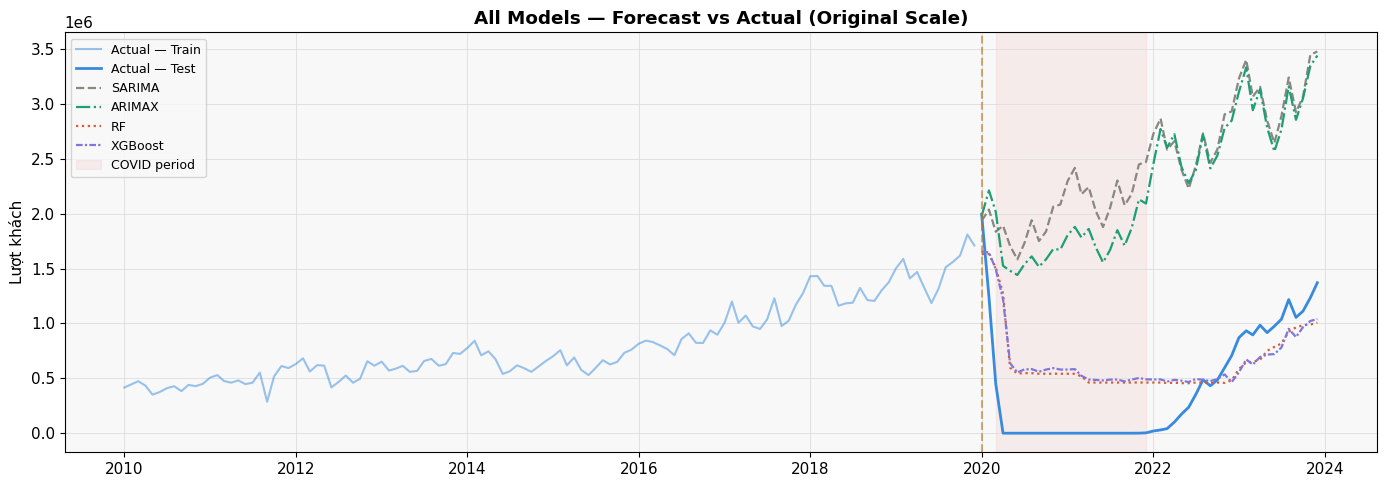

In [22]:
# ── Original scale ────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(train.index, np.expm1(s_train),
         color=BLUE, lw=1.5, alpha=0.5, label="Actual — Train")
plt.plot(test.index, np.expm1(s_test),
         color=BLUE, lw=2.0, label="Actual — Test")
for (mname, pred), ls in zip(fc_log.items(), styles):
    plt.plot(pred.index, np.expm1(pred),
             color=MODEL_COLORS[mname], lw=1.6, ls=ls, label=mname)
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.07, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
plt.title("All Models — Forecast vs Actual (Original Scale)",
          fontweight="bold")
plt.ylabel("Lượt khách")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step7_all_forecasts_orig.png", dpi=150, bbox_inches="tight")
plt.show()

- Original scale làm rõ hơn mức độ thất bại của SARIMA/ARIMAX trong COVID:
  forecast ~1.5–2M khách/tháng trong khi actual = 0
- ML forecast gần 0 trong COVID period → behaviorally correct
- Tất cả models underforecast Recovery — mức phục hồi cao hơn dự kiến

## 4. RMSE BY PERIOD — grouped bar chart

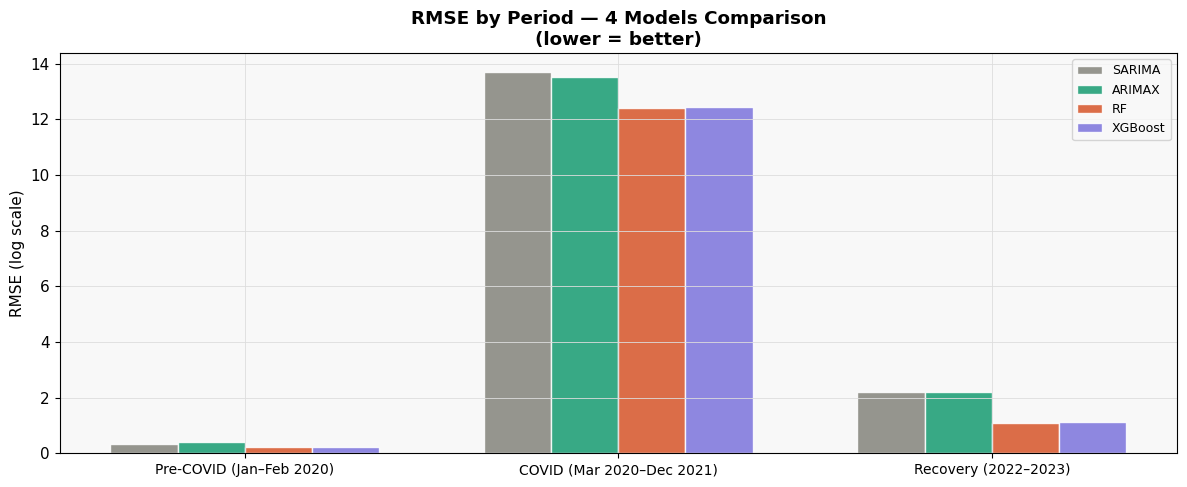

In [23]:
# ── RMSE by Period ──────────────────────────────────────────────────
period_order = ["Pre-COVID\n(Jan–Feb 2020)",
                "COVID\n(Mar 2020–Dec 2021)",
                "Recovery\n(2022–2023)"]
models_order = ["SARIMA", "ARIMAX", "RF", "XGBoost"]
 
x = np.arange(len(period_order))
width = 0.18
 
fig, ax = plt.subplots(figsize=(12, 5))
for i, model in enumerate(models_order):
    vals = [metrics_df[(metrics_df["Period"]==p) &
                       (metrics_df["Model"]==model)]["RMSE_log"].values[0]
            for p in period_order]
    bars = ax.bar(x + i*width - 1.5*width, vals, width,
                  label=model, color=MODEL_COLORS[model],
                  edgecolor="white", alpha=0.88)
 
period_labels_clean = [p.replace("\n", " ") for p in period_order]
ax.set_xticks(x)
ax.set_xticklabels(period_labels_clean, fontsize=10)
ax.set_ylabel("RMSE (log scale)")
ax.set_title("RMSE by Period — 4 Models Comparison\n(lower = better)",
             fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step7_rmse_by_period.png", dpi=150, bbox_inches="tight")
plt.show()

- **Pre-COVID**: chênh lệch nhỏ — tất cả models đều ổn trong normal conditions
- **COVID**: SARIMA tệ nhất (13.73), ML tốt nhất (12.40) — chênh ~10%
- **Recovery**: khoảng cách lớn nhất — RF (1.08) vs SARIMA (2.29) → ML tốt hơn 2x
- Recovery là period quan trọng nhất cho policy → ML có lợi thế thực tiễn rõ ràng

## 5. RESIDUAL COMPARISON

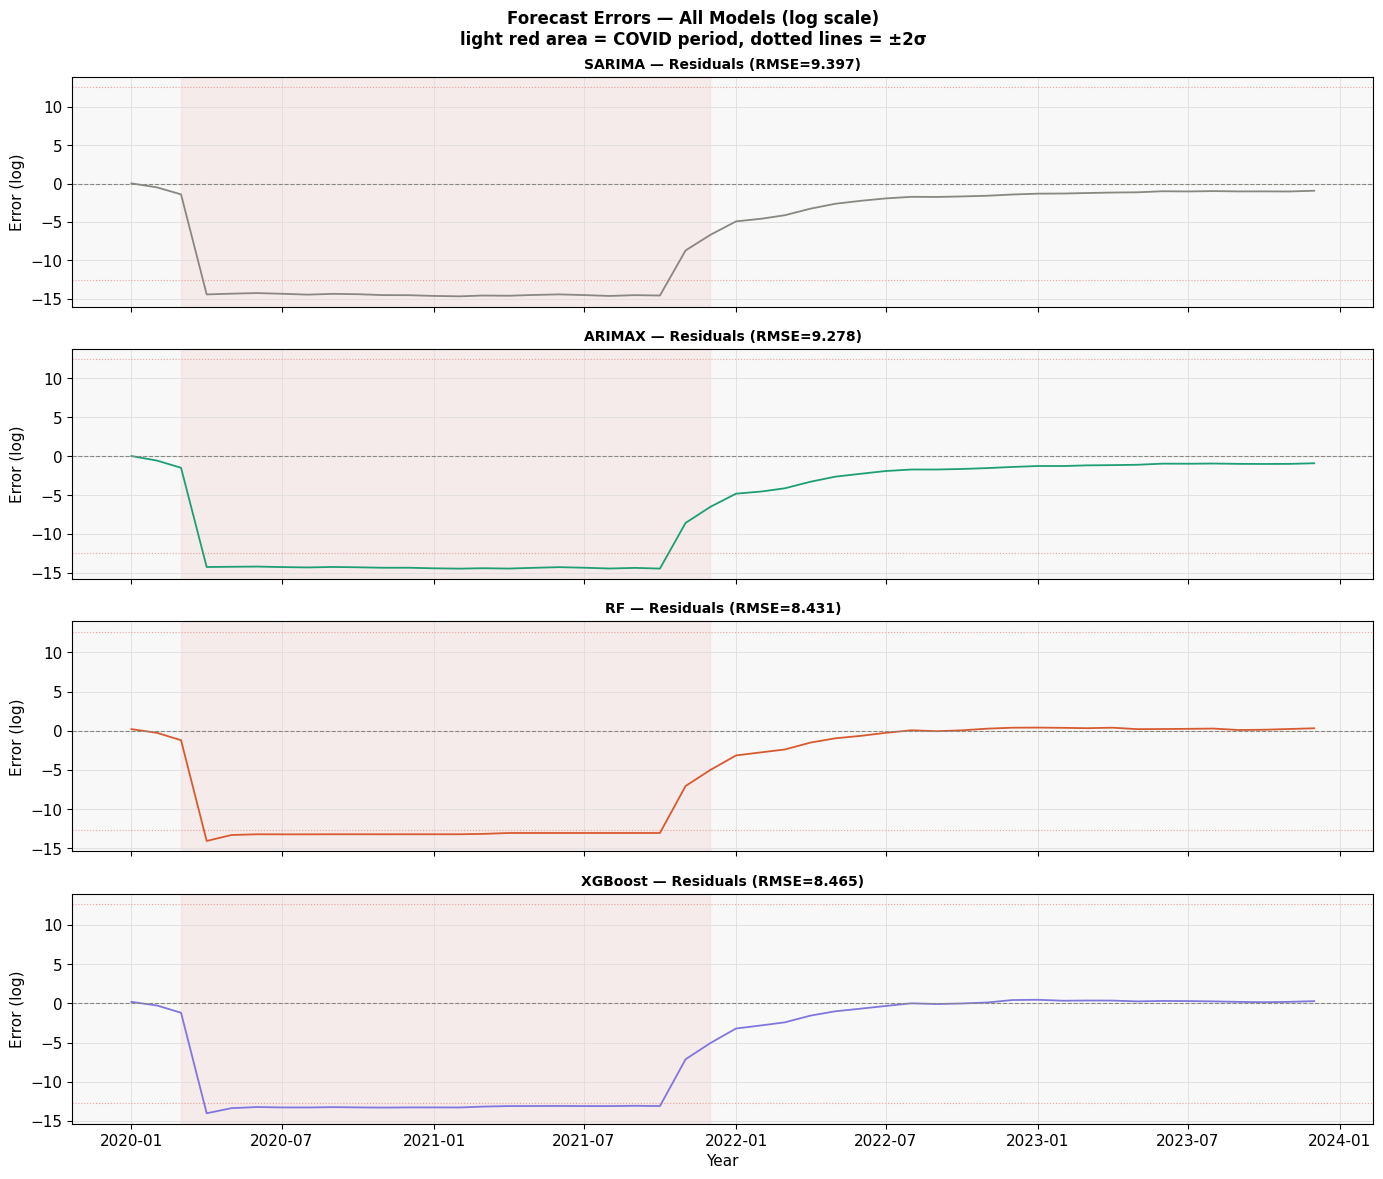

In [24]:
# ── Residuals by Model ─────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, (mname, pred) in zip(axes, fc_log.items()):
    err = s_test - pred
    ax.plot(err.index, err, color=MODEL_COLORS[mname], lw=1.3)
    ax.axhline(0, color=GRAY, lw=0.8, ls="--")
    ax.axhline( 2*err.std(), color=RED, lw=0.8, ls=":", alpha=0.5)
    ax.axhline(-2*err.std(), color=RED, lw=0.8, ls=":", alpha=0.5)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
               alpha=0.07, color=RED)
    rmse_val = np.sqrt(mean_squared_error(s_test, pred))
    ax.set_title(f"{mname} — Residuals (RMSE={rmse_val:.3f})",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("Error (log)")
 
axes[-1].set_xlabel("Year")
plt.suptitle("Forecast Errors — All Models (log scale)\n"
             "light red area = COVID period, dotted lines = ±2σ",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step7_residuals_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

- SARIMA/ARIMAX: residual spike lớn trong COVID (error ~13–14 log units) → systematic bias
- RF/XGB: residual nhỏ hơn và phân tán đều hơn qua các period
- Tất cả models: residual lớn nhất ở tháng 3–4/2020 (COVID shock đột ngột)
- RF/XGB residuals trong Recovery gần 0 → đây là lý do RMSE Recovery thấp

## 6. SUMMARY TABLE 

In [25]:
# ── FINAL SUMMARY TABLE ──────────────────────────────────────────────────
overall = metrics_df[metrics_df["Period"] == "Overall\n(2020–2023)"].set_index("Model")
covid   = metrics_df[metrics_df["Period"] == "COVID\n(Mar 2020–Dec 2021)"].set_index("Model")
recov   = metrics_df[metrics_df["Period"] == "Recovery\n(2022–2023)"].set_index("Model")
 
print("=" * 78)
print("  FINAL SUMMARY TABLE")
print("=" * 78)
print(f"\n  {'Model':<10} {'Overall RMSE':>14} {'COVID RMSE':>12} "
      f"{'Recovery RMSE':>15}")
print(f"  {'-'*70}")
for m in ["SARIMA", "ARIMAX", "RF", "XGBoost"]:
    best_overall = "★" if m == overall["RMSE_log"].idxmin() else " "
    print(f"  {m:<10} {overall.loc[m,'RMSE_log']:>13.4f}{best_overall} "
          f"{covid.loc[m,'RMSE_log']:>12.4f} "
          f"{recov.loc[m,'RMSE_log']:>15.4f} "
        )

  FINAL SUMMARY TABLE

  Model        Overall RMSE   COVID RMSE   Recovery RMSE
  ----------------------------------------------------------------------
  SARIMA            9.3975       13.6885          2.2032 
  ARIMAX            9.2779       13.5128          2.1834 
  RF                8.4309★      12.4017          1.0823 
  XGBoost           8.4648       12.4496          1.1058 


**Về forecast accuracy (RMSE):**
- ML > Econometric ở mọi period — RF là model tốt nhất về RMSE
- ARIMAX > SARIMA — search_trends cải thiện forecast, đặc biệt COVID period

**Về interpretability:**
- ARIMAX: hệ số `log_search_trends = 0.40` có ý nghĩa kinh tế rõ ràng
- ML: black box, không giải thích được tại sao forecast như vậy

**Về practical value:**
- ML không có confidence interval → không quantify được uncertainty
- ARIMAX có 95% CI → policy makers biết được range dự báo

**Kết luận tổng hợp:**
> *Nếu mục tiêu là accuracy → Random Forest. Nếu mục tiêu là understanding demand drivers → ARIMAX. Cho bài toán tourism policy, ARIMAX + RF là combo tối ưu: ARIMAX để explain, RF để benchmark.*

In [26]:
# Save summary
summary = pd.DataFrame({
    "Model":           ["SARIMA", "ARIMAX", "RF", "XGBoost"],
    "Overall_RMSE":    [overall.loc[m,"RMSE_log"] for m in ["SARIMA","ARIMAX","RF","XGBoost"]],
    "Overall_MAE":     [overall.loc[m,"MAE_log"]  for m in ["SARIMA","ARIMAX","RF","XGBoost"]],
    "COVID_RMSE":      [covid.loc[m,"RMSE_log"]   for m in ["SARIMA","ARIMAX","RF","XGBoost"]],
    "Recovery_RMSE":   [recov.loc[m,"RMSE_log"]   for m in ["SARIMA","ARIMAX","RF","XGBoost"]],
})
summary.to_csv("../outputs/evaluation_summary.csv", index=False)
print("  [✓] Saved: ../outputs/evaluation_summary.csv")

  [✓] Saved: ../outputs/evaluation_summary.csv
